# Test Virtual Inertia using the Synchronverter

### Model of the synchronous generator 

$$
\begin{aligned}
    \mathbf{v} &= -R_s \mathbf{i} - L_s\frac{d\mathbf{i}}{dt} + \mathbf{e} & (3)\\
    \mathbf{e} &= M_f i_f \dot{\theta} \bm{\widetilde{\sin}\theta}  - M_f \frac{di_f}{dt} \bm{\widetilde{\cos}\theta}	& (4)\\ 
    J \ddot{\theta} &= T_m - T_e - D_p \dot\theta  & (6) \\ 
    T_e &= M_f i_f \langle \mathbf{i}, \bm{\widetilde{\sin}\theta} \rangle & (7) \\
    P &= \dot \theta M_f i_f \langle \mathbf{i}, \bm{\widetilde{\sin} \theta\rangle} & (8) \\
    Q &= -\dot \theta M_f i_f \langle \mathbf{i}, \bm{\widetilde{\cos} \theta \rangle} & (9) \\
\end{aligned}  
$$
where
$$
\begin{aligned}
\mathbf{v} &= \begin{bmatrix} 
                        v_a \\
                        v_b \\
                        v_c 
            \end{bmatrix},
\mathbf{i} &= \begin{bmatrix} 
                        i_a \\
                        i_b \\ 
                        i_c 
            \end{bmatrix}, 
\mathbf{e} &= \begin{bmatrix} 
                        e_a \\
                        e_b \\
                        e_c \\ 
            \end{bmatrix} \\ 
\end{aligned}\\ 
\begin{aligned}  
\bm{\widetilde{\sin}\theta} &= \begin{bmatrix} 
					    	\sin \theta \\ 
						\sin (\theta - \frac{2\pi}{3}) \\
						\sin (\theta - \frac{4\pi}{3})
					    \end{bmatrix}, 
\bm{\widetilde{\cos}\theta} &= \begin{bmatrix} 
					    	\cos \theta \\ 
						\cos (\theta - \frac{2\pi}{3}) \\
						\cos (\theta - \frac{4\pi}{3})
					    \end{bmatrix}
\end{aligned}
$$

In control system lingo, this nonlinear system can be represented in state-space as below: 

| States | Variable | States | Variable |
|--------|----------|--------|----------|
| $x_1$ | $i_a$ | $x_8$ | $v_c$ |
| $x_2$ | $i_b$ | $x_9$ | $e_a$ |
| $x_3$ | $i_c$ | $x_{10}$ | $e_b$ |
| $x_4$ | $\theta$ | $x_{11}$ | $e_c$ |
| $x_5$ | $\dot{\theta}$ | $x_{12}$ | $T_e$ |
| $x_6$ | $v_a$ | $x_{13}$ | $P$ |
| $x_7$ | $v_b$ | $x_{14}$ | $Q$ |

$$

$$

| **Inputs** | $u_1$ | $u_2$ |
|------------|-------|-------|
| **Variables** | $T_m$ | $M_f i_f$ |




Equation (3) can be represented as

$$
\begin{bmatrix}
    \dot{x}_1 \\
    \dot{x}_2 \\
    \dot{x}_3 \\
\end{bmatrix} = \frac{1}{L_s} \left( -R_s \begin{bmatrix}
                        x_1 \\
                        x_2 \\
                        x_3 
                     \end{bmatrix} - \begin{bmatrix}
                                        x_6 \\
                                        x_7 \\ 
                                        x_8
                                     \end{bmatrix} + u_2 \begin{bmatrix}
                                        \sin x_4 \\
                                        \sin \left( x_4 - \frac{2\pi}{3}\right) \\ 
                                        \sin \left ( x_4 - \frac{4\pi}{3}\right)
                                     \end{bmatrix} \right)
$$

<!-- Equation (4) with second term zero, is as follows

<!-- $$ -->
<!-- \dot x_4 = \frac{1}{u_2} \begin{bmatrix}
                                \frac{x_9}{\sin x_4} \\
                                \frac{x_{10}}{\sin \left( x_4 - \frac{2\pi}{3}\right)} \\ 
                                \frac{x_{11}}{\sin \left ( x_4 - \frac{4\pi}{3}\right)}
                          \end{bmatrix} -->
<!-- $$ --> 

Equation (6) as 

$$
\dot x_5 = \frac{1}{J}\left[ u_1 - x_{12} - D_p x_5 \right] 
$$


Equation (7) as 

$$
x_{12} = u_2  \left( x_1 \sin(x_4) + x_2 \sin \left( x_4 - \frac{2\pi}{3}\right)  + x_3 \sin \left ( x_4 - \frac{4\pi}{3}\right) \right)
$$

Equation (8) as 
$$
x_{13} = x_5 u_2  \left( x_1 \sin(x_4) + x_2 \sin \left( x_4 - \frac{2\pi}{3}\right)  + x_3 \sin \left ( x_4 - \frac{4\pi}{3}\right) \right)
$$


Equation (9) as 

$$
x_{14} = - x_5 u_2 \left( x_1 \cos(x_4) + x_2 \cos \left( x_4 - \frac{2\pi}{3}\right)  + x_3 \cos \left ( x_4 - \frac{4\pi}{3}\right) \right)
$$


In [3]:
import numpy as np 
import control as ct 
import matplotlib.pyplot as plt 

print("python-control",ct.__version__)
print("NumPy version:", np.__version__)

python-control 0.10.2
NumPy version: 2.3.5


In [ ]:
def sg_update(t, x, u, params): 
    # get model parameters 
    R_s = params.get('R_s', 0.135); # Ohm 
    L_s = params.get('L_s', 0.45e-3); # Henry
    # f_g = params.get('f_g', 50); # Hz
    D_p = params.get('D_p', 0.206); # W/rad/s
    J = params.get('J', 4.052e-4); # W/rad
    
    # saturate the inputs? 

    # derivative of first five states 

    dx = np.zeros((5,))

    tilde_sin = np.array([
        np.sin(x[3]), 
        np.sin(x[3] - 2*np.pi/3),
        np.sin(x[3] - 4*np.pi/3) 
    ])

    # tilde_cos = np.array([
    #     np.cos(x[3]), 
    #     np.cos(x[3] - 2*np.pi/3),
    #     np.cos(x[3] - 4*np.pi/3) 
    # ])

    v = np.array([
        240, 
        240, 
        240
    ])

    # equation (3) and (4)
    dx[0:3] = (1 / L_s) * (-R_s * x[:3] - v + u[1] * tilde_sin)

    # dot x_4 = x_5  
    dx[3] = x[4]

    # equation 6 
    dx[4] = (1 / J) * (u[0] - np.dot(x[:3], tilde_sin) - D_p * x[4])

    return dx

def sg_output(t, x, u, params):

    
    # 
    return x 

# sg params 
sg_params = {'R_s': 0.135, 'L_s': 0.45e-3, 'D_p': 0.206, 'J': 4.052e-4}

# sg model 
sg = ct.nlsys(
    sg_update, 
    sg_output, 
    states=5, 
    inputs=['$T_m$','$M_f i_f$'], 
    outputs = ['$i_a$', '$i_b$', '$i_c$', '$\theta$','$\omega$,'],
    # outputs=['$i_a$', '$i_b$', '$i_c$', '$\theta$','$\omega$,', '$e_a$', '$e_b$', '$e_c$', '$T_e$', '$P$','$Q$'], 
    params=sg_params,
)

In [30]:
# open loop simulation 

# define the time interval that we want to use for the simulation 
timepts = np.linspace(0,10,1000) 

u = [
    1 * np.ones_like(timepts), 
    1 * np.ones_like(timepts)
]

# simulate the sg dynamics
response = ct.input_output_response(sg, timepts, u, 0)

In [31]:
time, outputs, inputs = response.time, response.outputs, response.inputs 

In [46]:
def calculate_dvs(outputs, inputs):

    i_a, i_b, i_c, theta, omega = outputs
    u_1, u_2 = inputs
    
    tilde_sin = np.array([
        np.sin(theta), 
        np.sin(theta - 2*np.pi/3),
        np.sin(theta - 4*np.pi/3) 
    ])

    tilde_cos = np.array([
        np.cos(theta), 
        np.cos(theta - 2*np.pi/3),
        np.cos(theta - 4*np.pi/3) 
    ])
    
    back_emf = u_2 * omega * tilde_sin 
    e_a, e_b, e_c = back_emf
    T_e = u_2 * (i_a * tilde_sin[0] + i_b * tilde_sin[1] + i_c * tilde_sin[2] )
    P = omega * u_2 * (i_a * tilde_sin[0] + i_b * tilde_sin[1] + i_c * tilde_sin[2] )
    Q = - omega * u_2 * (i_a * tilde_cos[0] + i_b * tilde_cos[1] + i_c * tilde_cos[2] ) 

    return i_a, i_b, i_c, theta, omega, e_a, e_b, e_c, T_e, P, Q 

In [47]:
i_a, i_b, i_c, theta, omega, e_a, e_b, e_c, T_e, P, Q = calculate_dvs(outputs, inputs)

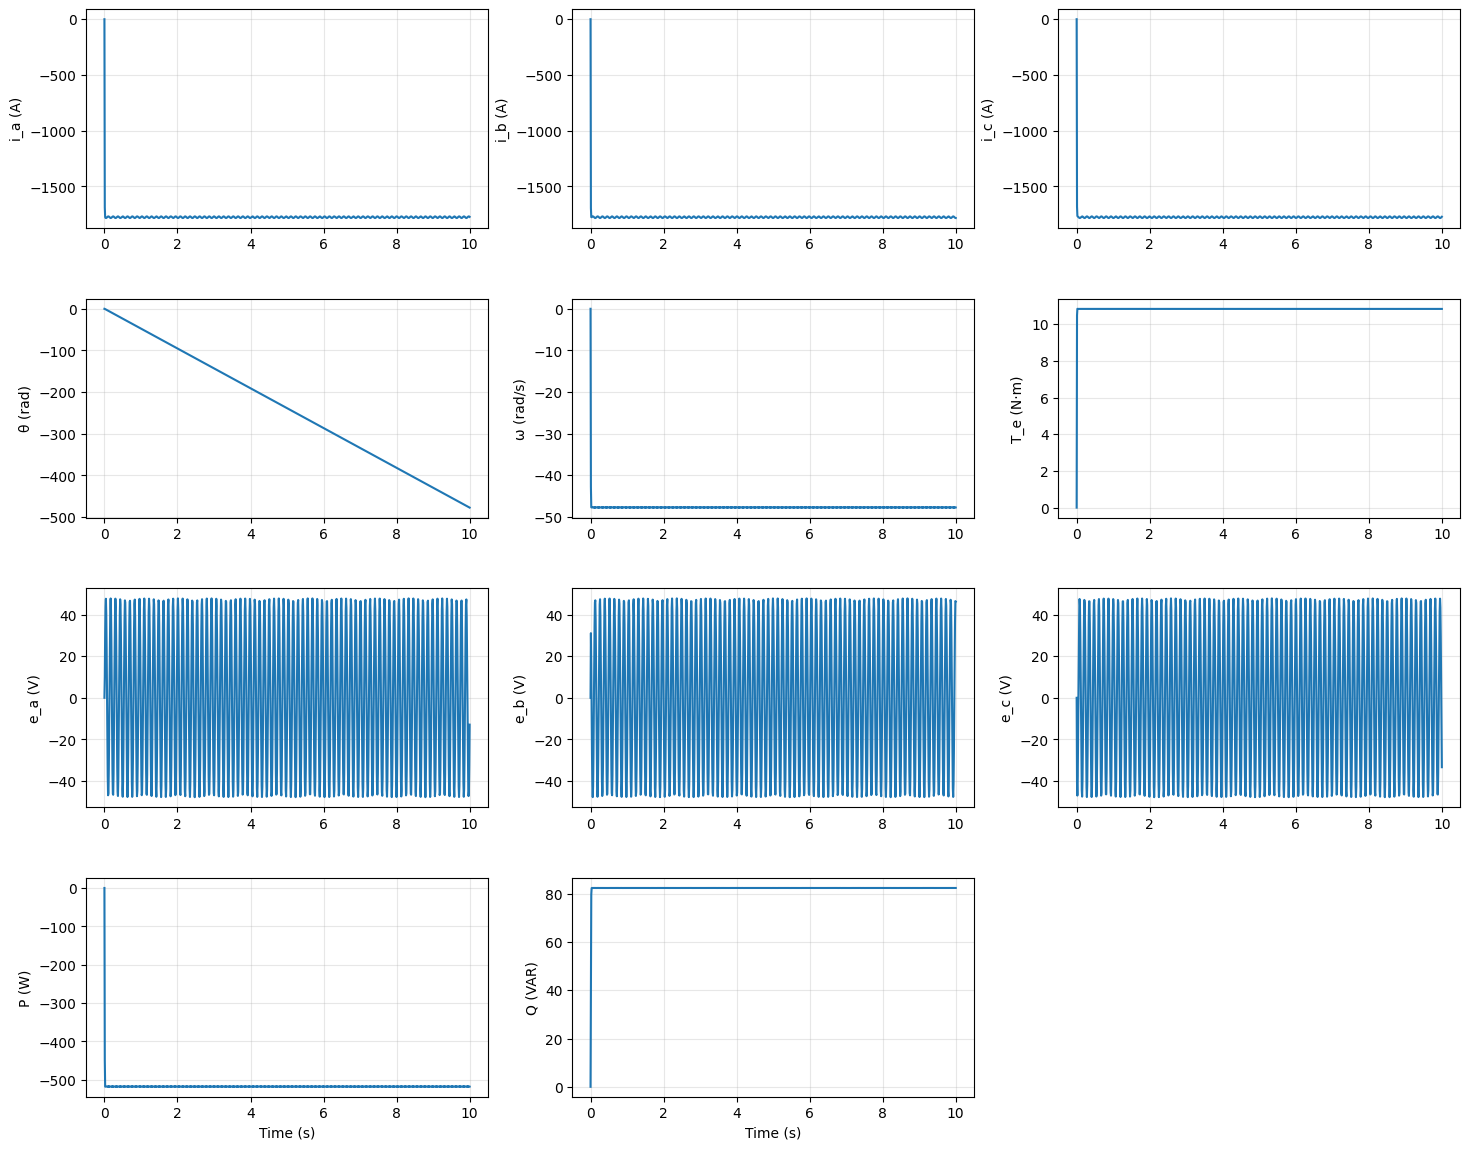

In [48]:
import matplotlib.pyplot as plt
import numpy as np

def plot_timeseries(timepts, i_a, i_b, i_c, theta, omega, e_a, e_b, e_c, T_e, P, Q):
    """
    Plot time series data for electrical machine variables.
    
    Parameters:
    -----------
    timepts : array-like
        Time points (x-axis)
    i_a, i_b, i_c : array-like
        Phase currents
    theta : array-like
        Rotor angle
    omega : array-like
        Angular velocity
    e_a, e_b, e_c : array-like
        Phase voltages
    T_e : array-like
        Electromagnetic torque
    P : array-like
        Real power
    Q : array-like
        Reactive power
    """
    fig, axes = plt.subplots(4, 3, figsize=(15, 12))
    fig.tight_layout(pad=3.0)
    
    # Phase currents
    axes[0, 0].plot(timepts, i_a)
    axes[0, 0].set_ylabel('i_a (A)')
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].plot(timepts, i_b)
    axes[0, 1].set_ylabel('i_b (A)')
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[0, 2].plot(timepts, i_c)
    axes[0, 2].set_ylabel('i_c (A)')
    axes[0, 2].grid(True, alpha=0.3)
    
    # Mechanical variables
    axes[1, 0].plot(timepts, theta)
    axes[1, 0].set_ylabel('θ (rad)')
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].plot(timepts, omega)
    axes[1, 1].set_ylabel('ω (rad/s)')
    axes[1, 1].grid(True, alpha=0.3)
    
    axes[1, 2].plot(timepts, T_e)
    axes[1, 2].set_ylabel('T_e (N·m)')
    axes[1, 2].grid(True, alpha=0.3)
    
    # Phase voltages
    axes[2, 0].plot(timepts, e_a)
    axes[2, 0].set_ylabel('e_a (V)')
    axes[2, 0].grid(True, alpha=0.3)
    
    axes[2, 1].plot(timepts, e_b)
    axes[2, 1].set_ylabel('e_b (V)')
    axes[2, 1].grid(True, alpha=0.3)
    
    axes[2, 2].plot(timepts, e_c)
    axes[2, 2].set_ylabel('e_c (V)')
    axes[2, 2].grid(True, alpha=0.3)
    
    # Power
    axes[3, 0].plot(timepts, P)
    axes[3, 0].set_ylabel('P (W)')
    axes[3, 0].set_xlabel('Time (s)')
    axes[3, 0].grid(True, alpha=0.3)
    
    axes[3, 1].plot(timepts, Q)
    axes[3, 1].set_ylabel('Q (VAR)')
    axes[3, 1].set_xlabel('Time (s)')
    axes[3, 1].grid(True, alpha=0.3)
    
    # Hide the last empty subplot
    axes[3, 2].axis('off')
    
    plt.show()

# Example usage:
plot_timeseries(timepts, i_a, i_b, i_c, theta, omega, e_a, e_b, e_c, T_e, P, Q)